In [1]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import muspan as ms
from itertools import zip_longest
from typing import List, Tuple, Optional
import math
from functools import partial
import seaborn as sns
from scipy import stats
import pathlib

In [ ]:
# unordered_met_nos = [2,2,1,1,3,17,4,23,7,13]
# unordered_domains_order = ['AKPT_Liver_Mets_4d_1_Region_1', 
#            'AKPT_Liver_Mets_4d_1_Region_2', 
#            'AKPT_Liver_Mets_4d_2_Region_1', 
#            'AKPT_Liver_Mets_4d_3_Region_1', 
#            'AKPT_Liver_Mets_4d_5_Region_1', 
#            'AKPT_Liver_Mets_28d_1_Region_1',
#            'AKPT_Liver_Mets_28d_1_Region_2',
#            'AKPT_Liver_Mets_28d_2_Region_1',
#            'AKPT_Liver_Mets_28d_2_Region_2',
#            'AKPT_Liver_Mets_28d_3_Region_1']

In [2]:
directory = pathlib.Path("../outputs/In_out")
i=0
list_of_files = []
for item in directory.rglob("*"):
    if item.is_file():
            if str(item) != str(directory)+'/.DS_Store':
                list_of_files.append(str(item))
            i+=1
names = [x.replace('../domains_with_mets/', '').replace('.muspan', '') for x in list_of_files]

In [8]:
print(names)

['../outputs/In_out/Sample_4d_5', '../outputs/In_out/Sample_4d_1_2', '../outputs/In_out/Sample_28d_2_2', '../outputs/In_out/Sample_4d_3', '../outputs/In_out/Sample_28d_2', '../outputs/In_out/Sample_4d_1', '../outputs/In_out/Sample_28d_1', '../outputs/In_out/Sample_4d_2', '../outputs/In_out/Sample_28d_3', '../outputs/In_out/Sample_28d_1_2']


In [3]:
met_nos = [1,1,2,3,7,17,2,23,13,4]
domains_order = ['AKPT_Liver_Mets_4d_2_Region_1', 
                'AKPT_Liver_Mets_4d_3_Region_1', 
                'AKPT_Liver_Mets_4d_1_Region_2', 
                'AKPT_Liver_Mets_4d_5_Region_1',
                'AKPT_Liver_Mets_28d_2_Region_2', 
                'AKPT_Liver_Mets_28d_1_Region_1', 
                'AKPT_Liver_Mets_4d_1_Region_1',
                'AKPT_Liver_Mets_28d_2_Region_1',
                'AKPT_Liver_Mets_28d_3_Region_1',
                'AKPT_Liver_Mets_28d_1_Region_2']
# AKPT_Liver_Mets_4d_4_Region_1

In [19]:
print(domain_names)

['AKPT_Liver_Mets_4d_2_Region_1', 'AKPT_Liver_Mets_4d_3_Region_1', 'AKPT_Liver_Mets_4d_1_Region_2', 'AKPT_Liver_Mets_4d_5_Region_1', 'AKPT_Liver_Mets_28d_2_Region_2', 'AKPT_Liver_Mets_28d_1_Region_1', 'AKPT_Liver_Mets_4d_1_Region_1', 'AKPT_Liver_Mets_28d_2_Region_1', 'AKPT_Liver_Mets_28d_3_Region_1', 'AKPT_Liver_Mets_28d_1_Region_2']


In [4]:
list_of_domains = []
for i in range(len(list_of_files)):
    list_of_domains.append(ms.io.load_domain(list_of_files[i], print_summary=False))

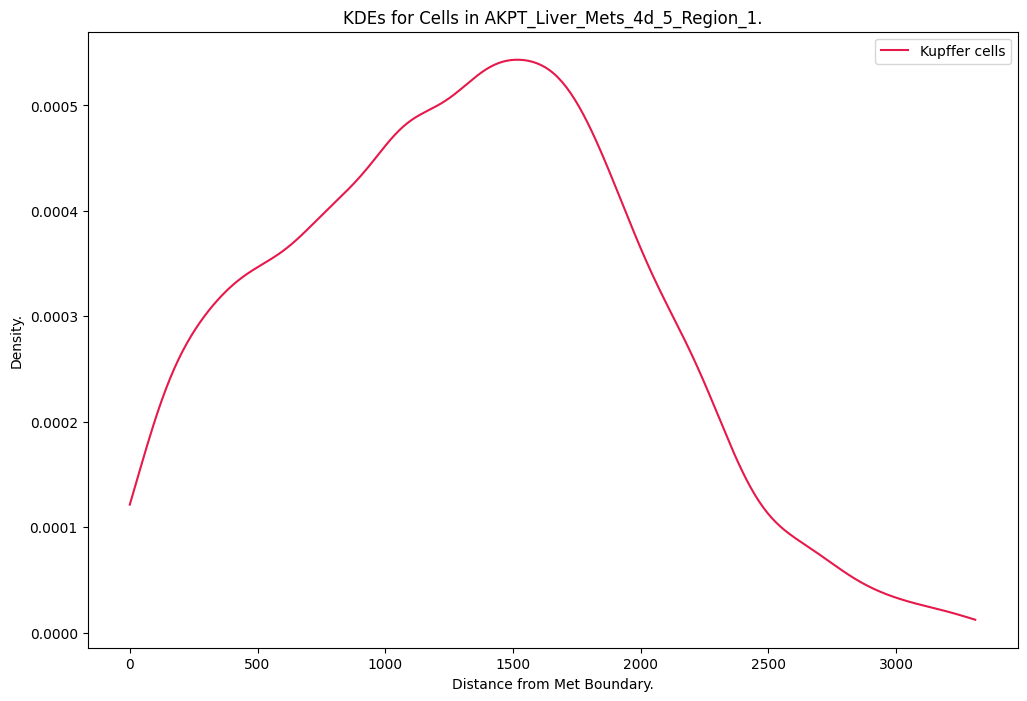

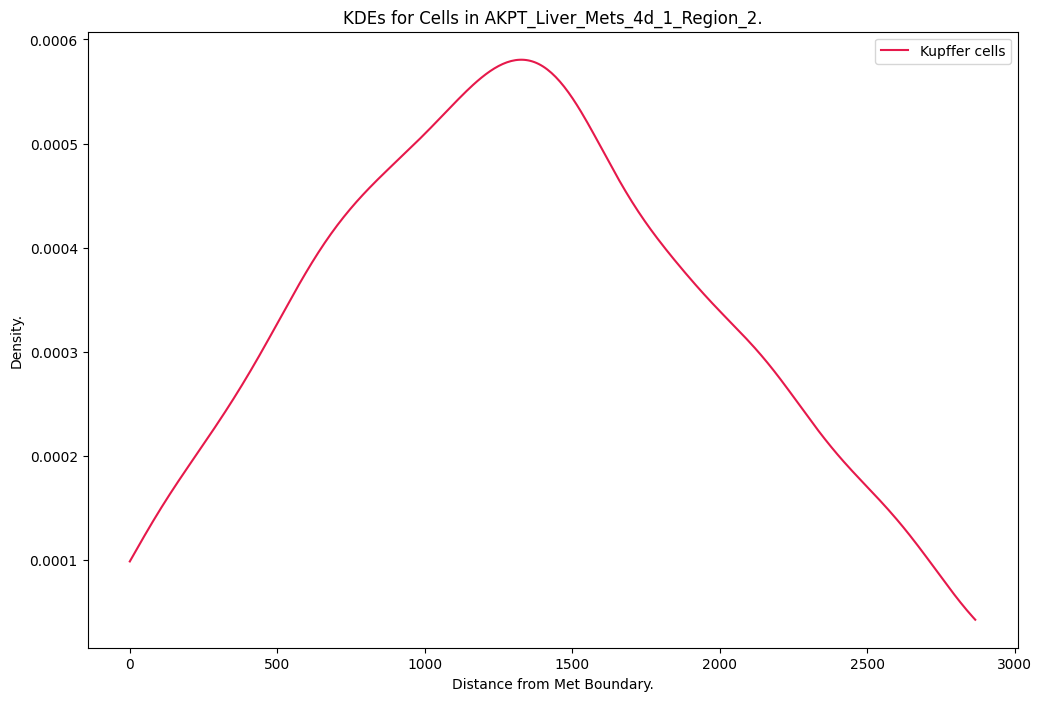

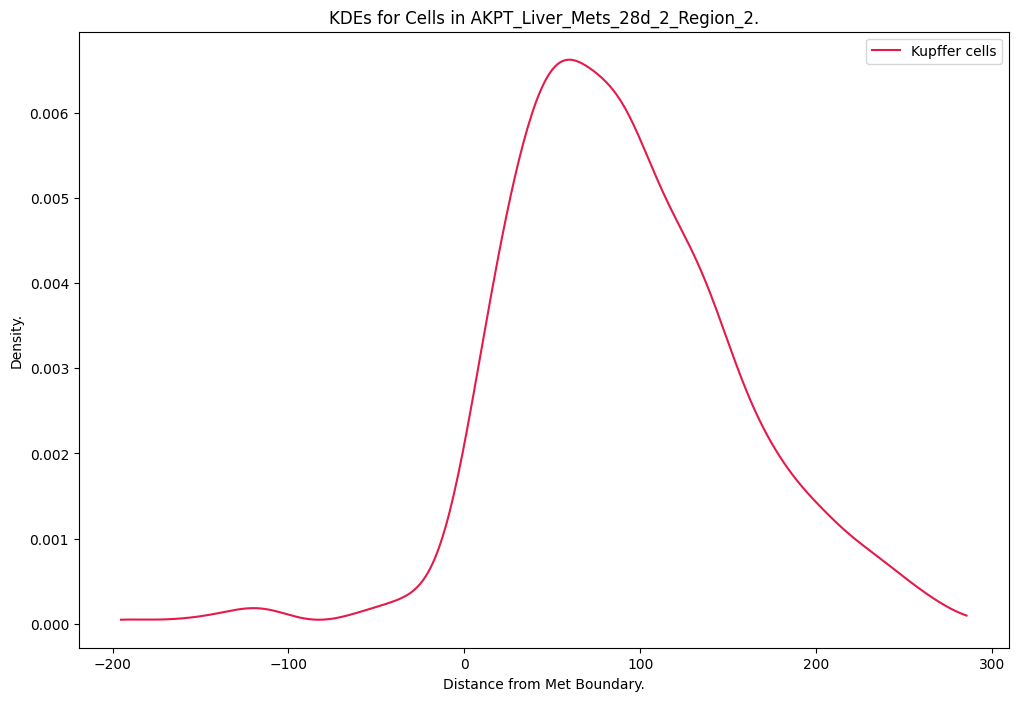

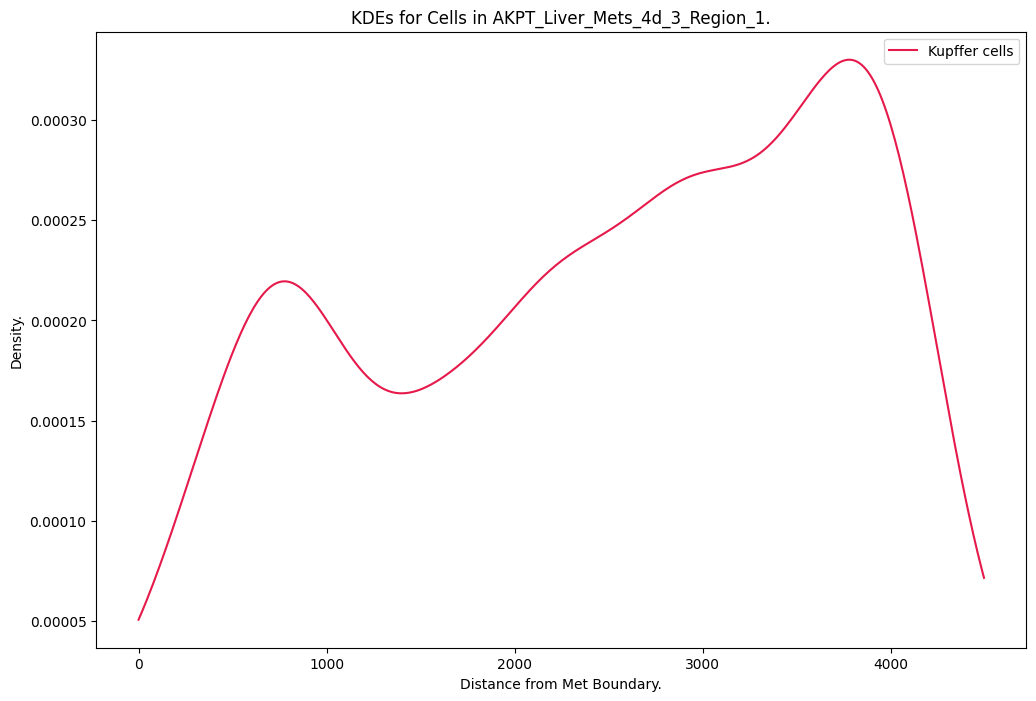

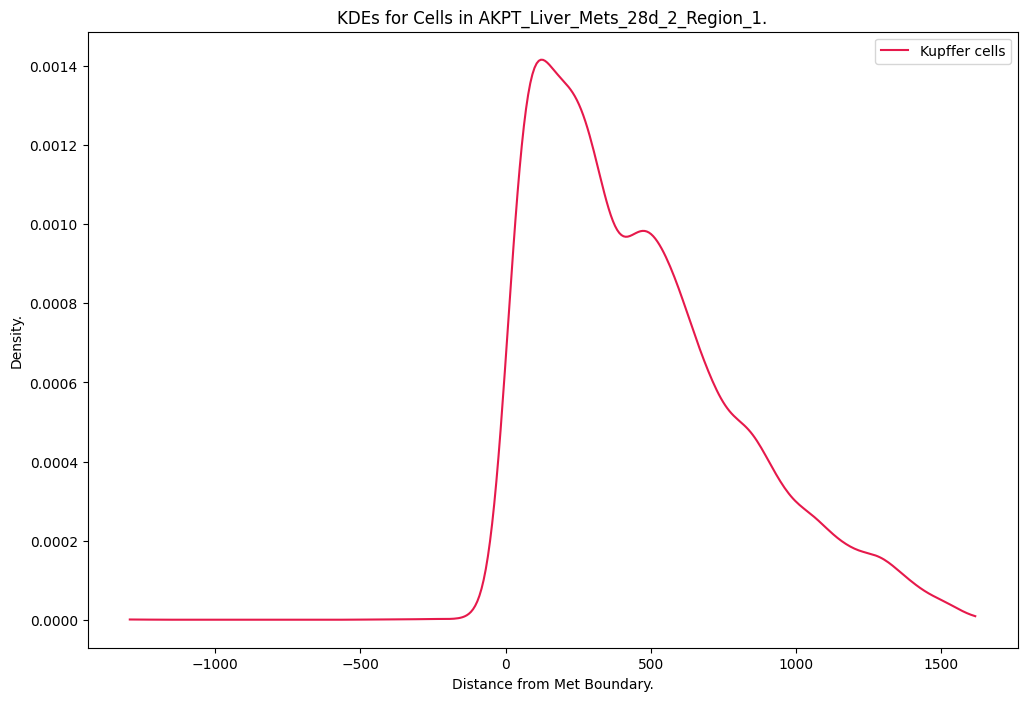

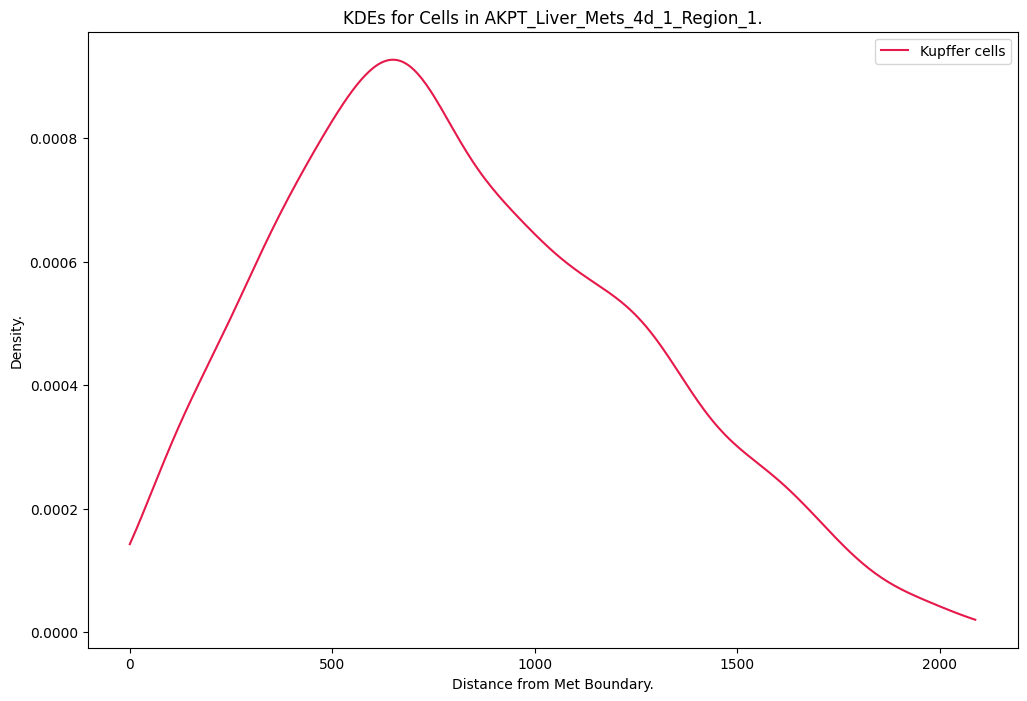

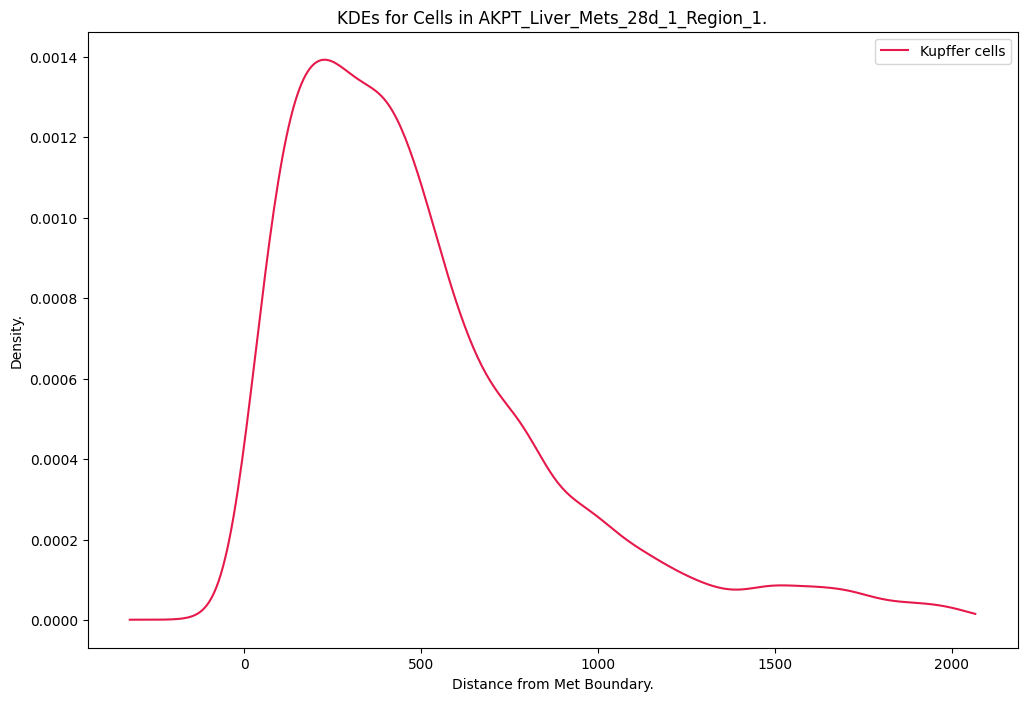

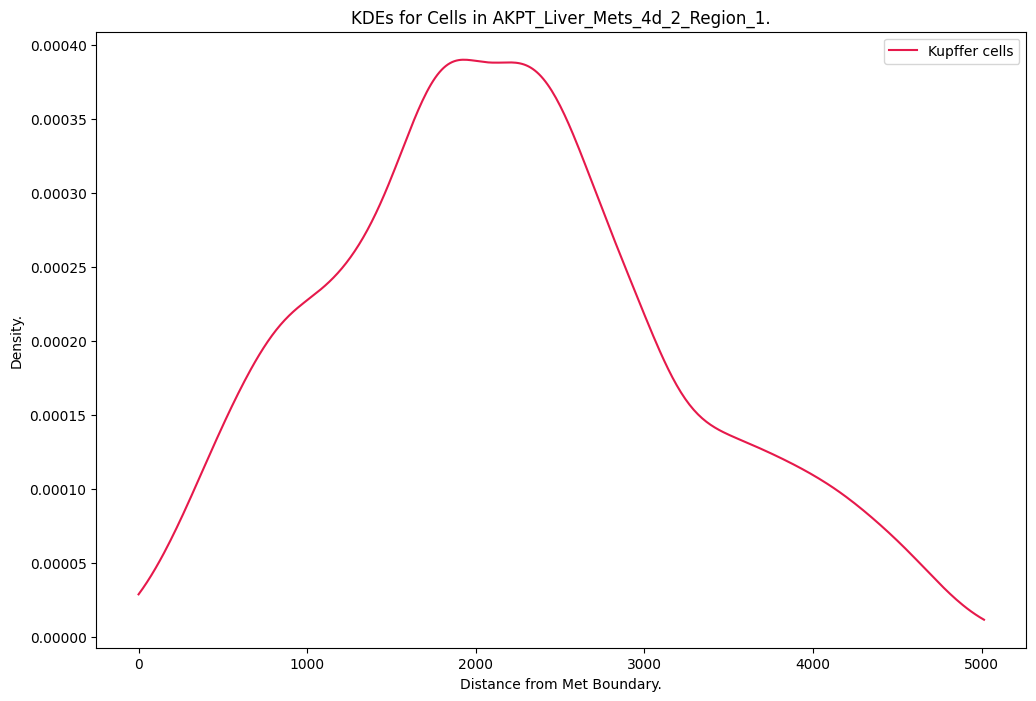

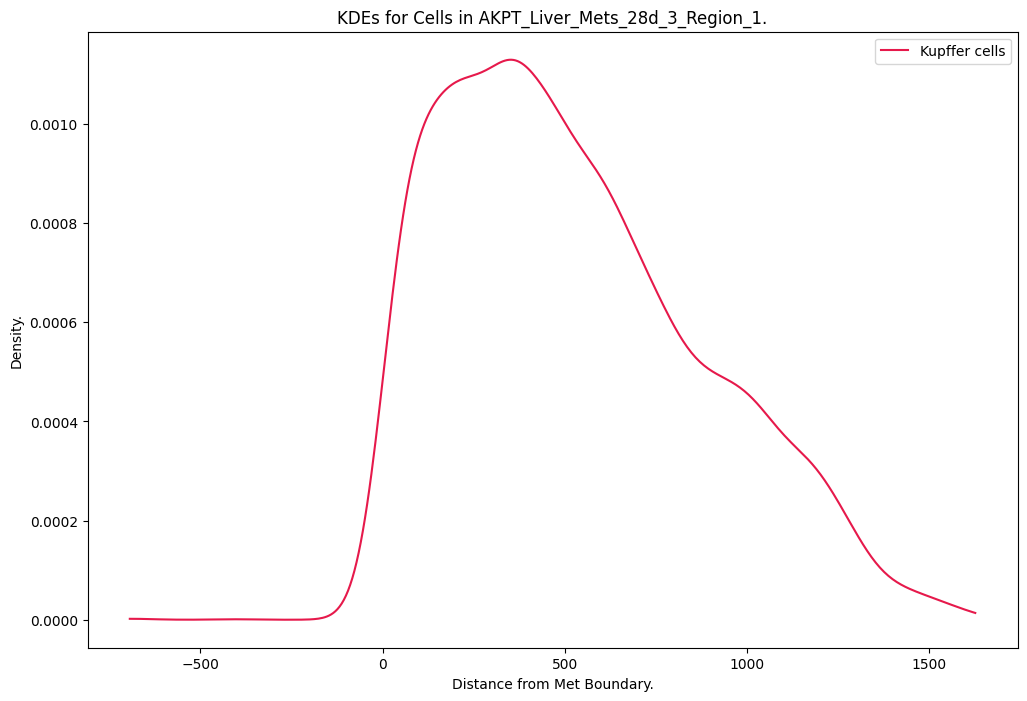

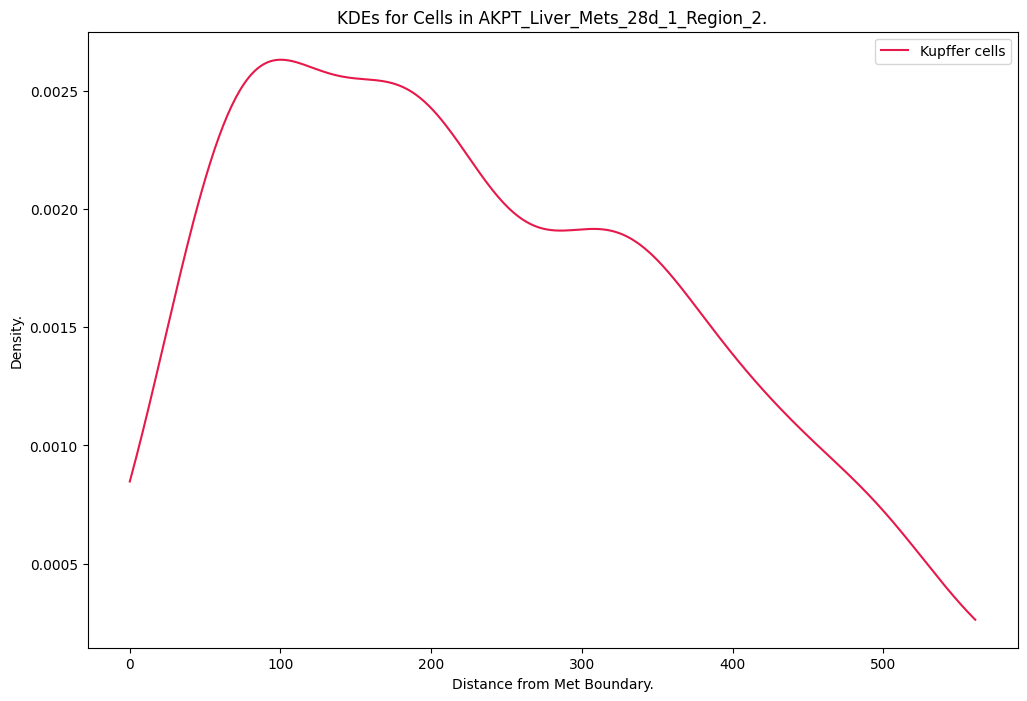

In [5]:
# specify cell type of interest
celltypes = ['Kupffer cells'] #'WNT-high CRC stem-like cells', 'WNT-high CRC cells', 'Wnt-low CRC cells']
label_name = 'Detailed celltype (liver)'

colours = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000']
list_of_axes = []
list_of_figs = []
list_of_max_met_dists = []
list_of_max_out_dists = []
all_met_distances = []
all_out_distances = []
all_regional_max_met_dists = []
for dom in range(len(list_of_domains)):
    domain = list_of_domains[dom]
    met_no = met_nos[domains_order.index(str(domain.name))]
    one_domain_met_distances = []
    one_domain_out_distances = []
    for region_no in range(met_no):
        met_distances = np.load('../outputs/Useful_Data/'+str(domain.name)+'_inside_Met_'+str(region_no+1)+'.npy', allow_pickle=True)
        one_domain_met_distances.append(met_distances)
    out_distances = np.load('../outputs/Useful_Data/'+str(domain.name)+'_outside_to_all_Mets.npy', allow_pickle=True)
    # one_domain_out_distances.append(out_distances)
    all_out_distances.append(out_distances)
    all_met_distances.append(one_domain_met_distances)

for dom in range(len(list_of_domains)):
    domain = list_of_domains[dom]
    met_no = met_nos[domains_order.index(str(domain.name))]
    # figures
    fig, axes = plt.subplots(1, 1, figsize=(12, 8))
    axes.set_title('KDEs for Cells in ' +str(domain.name)+'.')
    axes.set_xlabel('Distance from Met Boundary.')
    axes.set_ylabel('Density.')
    list_of_axes.append(axes)
    list_of_figs.append(fig)

    # met distances
    max_met_dist=0
    regional_max_met_dists = []
    shape_cell_distances = all_met_distances[dom]
    for region_no in range(met_no):
        distances = shape_cell_distances[region_no][1]#[sublist[1] for sublist in shape_cell_distances[region_no]]
        regional_max_met_dists.append(np.max(distances))
        if np.max(distances) > max_met_dist:
            max_met_dist = np.max(distances)
    list_of_max_met_dists.append(max_met_dist)
    all_regional_max_met_dists.append(regional_max_met_dists)

    # out distances
    shape_cell_distances_out = all_out_distances[domains_order.index(str(domain.name))]
    distances_out = [sublist[1] for sublist in shape_cell_distances_out]
    list_of_max_out_dists.append(np.max(distances_out))


all_domains_met_distances_joined = []
for dom in range(len(list_of_domains)):
    for celltype_no in range(len(celltypes)):
        celltype = celltypes[celltype_no]
        all_relevant_distances = []
        overall_x_min = 0
        domain = list_of_domains[dom]
        met_no = met_nos[domains_order.index(str(domain.name))]
        ### cell_type : collection or label
            # the collection or label of the objects that you would like to compute the shaped cross-pcf metric for - soon you will be able to calculate
            # for several cell types and return each one separately - currently need to set cell type to population, this is just here for future purposes
        all_normalised_distances = []
        # loop through each subshape
        all_kdes = []
        all_regions_distances = []
        for region_no in range(met_no):
            query_cell = ms.query.query(domain, ('label', label_name), 'is', celltype)
            specific_cell_IDs = ms.query.return_object_IDs_from_query_like(domain,query_cell,bypass_checks=True)

            shape_cell_distances = all_met_distances[dom][region_no]
            distances = [shape_cell_distances[1][i] for i in range(len(shape_cell_distances[0])) if shape_cell_distances[0][i] in specific_cell_IDs]
            # normalised_distances = distances/all_regional_max_met_dists[dom][region_no]
            all_regions_distances.append(distances)
            if len(distances) > 1:
                x_max = np.max(distances)
                x_min = -x_max
                if x_min < overall_x_min:
                    overall_x_min = x_min
                kde = stats.gaussian_kde(distances)
                x_eval = np.linspace(0, x_max, num=200)
                array_temp = np.array(x_eval)*-1
                x = list(array_temp)
                # list_of_axes[dom].plot(x, kde(x_eval), color = colours[region_no])
                distances_new = [-x for x in distances]
                all_relevant_distances.extend(distances_new)

        
        # x_eval = np.linspace(0, 1, num=200)
        # average_kde = stats.gaussian_kde(all_normalised_distances)
        # list_of_axes[dom].plot(x_eval, average_kde(x_eval), linestyle = 'dashed', color = colours[region_no], label=celltype)

        query_cell = ms.query.query(domain, ('label', label_name), 'is', celltype)
        specific_cell_IDs = ms.query.return_object_IDs_from_query_like(domain,query_cell,bypass_checks=True)

        shape_cell_distances = all_out_distances[dom]
        distances = [shape_cell_distances[1][i] for i in range(len(shape_cell_distances[0])) if shape_cell_distances[0][i] in specific_cell_IDs]
        # normalised_distances = [a/(a+b) for a,b in zip(distances, distances1)]
        x_max = 0
        if len(distances) > 1:
            all_relevant_distances.extend(distances)
            x_max = np.max(distances)
            kde = stats.gaussian_kde(distances)
            x_eval = np.linspace(0, x_max, num=200)
            # list_of_axes[dom].plot(x_eval, kde(x_eval), color = colours[region_no+1],label=celltype)
        # print(np.min(all_relevant_distances))
        # print(overall_x_min)
        if len(all_relevant_distances) > 1:
            kde = stats.gaussian_kde(all_relevant_distances)
            x_eval = np.linspace(overall_x_min, x_max, num=400)
            list_of_axes[dom].plot(x_eval, kde(x_eval), color = colours[celltype_no], label=celltype)


for dom in range(len(list_of_domains)):
    leg = list_of_axes[dom].legend()
    list_of_figs[dom].savefig('../outputs/WNT_plots/WNT_distribution_for_'+str(list_of_domains[dom].name)+'.png')